Number of good V points: 76


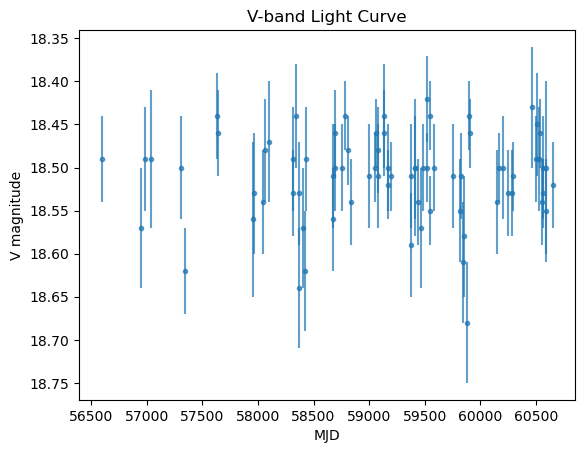

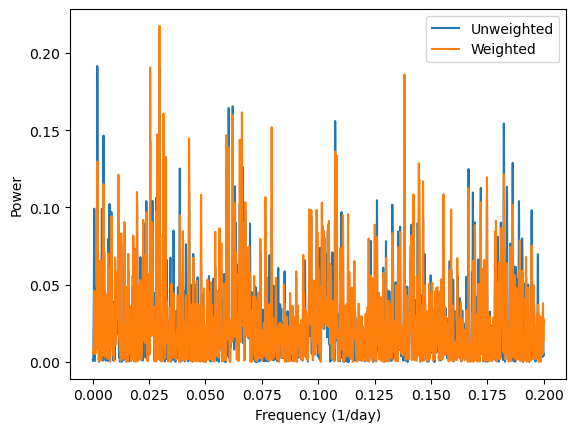

Best period (days): 33.758687465652116
Phase-folded amplitude (mag): 0.17249999999999943


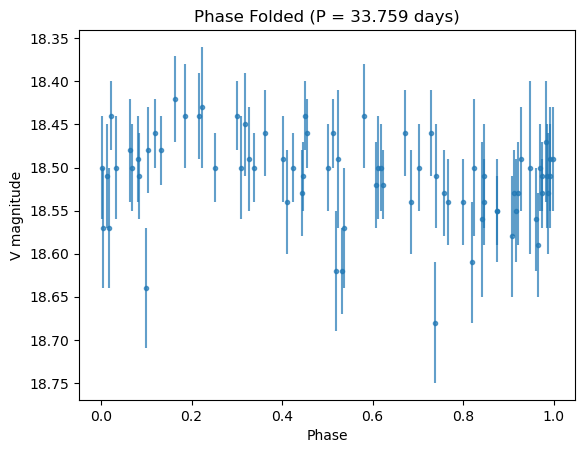

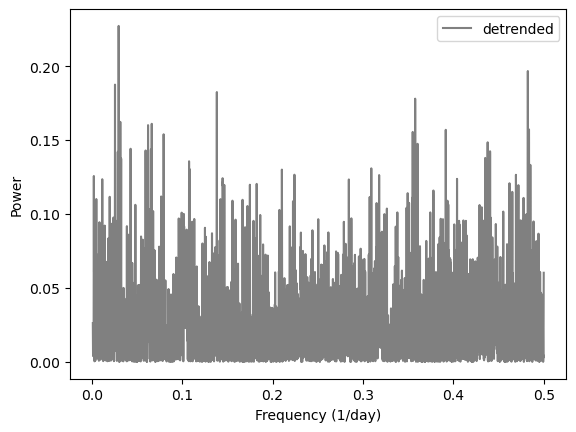

False Alarm Probability: 0.04203444257011719


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

filename = "M31-004522.58.tab.txt"

data = np.genfromtxt(
    filename,
    skip_header=1,
    dtype=str
)

mjd = data[:, 0].astype(float)

V_mag_raw = data[:, 1]
V_err_raw = data[:, 2]

valid_mag = V_mag_raw != "--.---"

valid_err = V_err_raw != "-.---"

mask = valid_mag & valid_err

mjd = mjd[mask]
V_mag = V_mag_raw[mask].astype(float)
V_err = V_err_raw[mask].astype(float)

print("Number of good V points:", len(V_mag))

plt.figure()
plt.errorbar(mjd, V_mag, yerr=V_err, fmt='.', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("MJD")
plt.ylabel("V magnitude")
plt.title("V-band Light Curve")
plt.show()


min_freq = 0.0001   #long timescale
max_freq = 0.2      #shorter timescale


ls_unweighted = LombScargle(mjd, V_mag)
frequency, power_unweighted = ls_unweighted.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq
)

ls_weighted = LombScargle(mjd, V_mag, dy=V_err)
power_weighted = ls_weighted.power(frequency)

plt.figure()
plt.plot(frequency, power_unweighted, label="Unweighted")
plt.plot(frequency, power_weighted, label="Weighted")
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()


best_freq = frequency[np.argmax(power_weighted)]
best_period = 1 / best_freq

print("Best period (days):", best_period)


phase = (mjd % best_period) / best_period

idx = np.argsort(phase)
phase_sorted = phase[idx]
mag_sorted = V_mag[idx]

amp_phase = np.percentile(mag_sorted, 95) - np.percentile(mag_sorted, 5)
print("Phase-folded amplitude (mag):", amp_phase)

plt.figure()
plt.errorbar(phase, V_mag, yerr=V_err, fmt='.', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("Phase")
plt.ylabel("V magnitude")
plt.title(f"Phase Folded (P = {best_period:.3f} days)")
plt.show()


from scipy.signal import detrend

V_detrended = detrend(V_mag)

ls = LombScargle(mjd, V_detrended, dy=V_err)
frequency, power = ls.autopower(minimum_frequency=0.001, maximum_frequency=0.5)

plt.figure()
plt.plot(frequency, power, label="detrended", color='grey')
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

best_power = np.max(power)
fap = ls.false_alarm_probability(best_power)
print("False Alarm Probability:", fap)